imports

In [39]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path

configuration

In [40]:
INPUT_FILE  = Path("../../data/raw/icse_affiliations.json")
OUTPUT_DIR  = Path("figures/isce")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

Load & deduplicate

In [41]:
with open(INPUT_FILE) as f:
    raw = json.load(f)
 
df = (
    pd.DataFrame(raw)
    .dropna(subset=["country_code"])
    .drop_duplicates(subset=["doi", "year", "country_code"])
    .copy()
)
 
print(f"Loaded {len(df):,} deduplicated rows across {df.year.nunique()} years")

Loaded 3,929 deduplicated rows across 15 years


region mapping

In [42]:
REGION_MAP = {
    "AU": "Asia-Pacific", "NZ": "Asia-Pacific", "CN": "Asia-Pacific",
    "IN": "Asia-Pacific", "TH": "Asia-Pacific", "SG": "Asia-Pacific",
    "JP": "Asia-Pacific", "KR": "Asia-Pacific",
    "US": "North America", "CA": "North America", "MX": "North America",
    "DE": "Europe", "FR": "Europe", "GB": "Europe", "IT": "Europe",
    "ES": "Europe", "NL": "Europe", "SE": "Europe", "FI": "Europe",
    "DK": "Europe", "NO": "Europe", "AT": "Europe", "BE": "Europe",
    "CH": "Europe", "PL": "Europe", "PT": "Europe", "CZ": "Europe",
    "IE": "Europe", "HU": "Europe", "RO": "Europe", "SI": "Europe",
    "IS": "Europe", "LU": "Europe", "HR": "Europe", "TR": "Europe",
    "GR": "Europe",
    "BR": "Latin America", "AR": "Latin America", "CL": "Latin America",
    "CO": "Latin America", "MX": "Latin America",
    "TN": "Africa & Middle East", "DZ": "Africa & Middle East",
    "JO": "Africa & Middle East", "ZA": "Africa & Middle East",
    "EG": "Africa & Middle East",
}
 
REGION_ORDER = [
    "Europe",
    "North America",
    "Asia-Pacific",
    "Latin America",
    "Africa & Middle East",
    "Unknown",
]
 
REGION_COLORS = {
    "Europe":               "#3266ad",
    "North America":        "#e07b3a",
    "Asia-Pacific":         "#3aa66b",
    "Latin America":        "#b04db0",
    "Africa & Middle East": "#c0474a",
    "Unknown":              "#888780",
}
 
df["region"] = df["country_code"].map(REGION_MAP).fillna("Unknown")
 
# ── Build per-year region percentages ─────────────────────────────────────────
 
region_year = (
    df.groupby(["year", "region"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=REGION_ORDER, fill_value=0)
)
region_pct = region_year.div(region_year.sum(axis=1), axis=0) * 100
years = region_pct.index.tolist()

plot 1: line chart--regional share over time

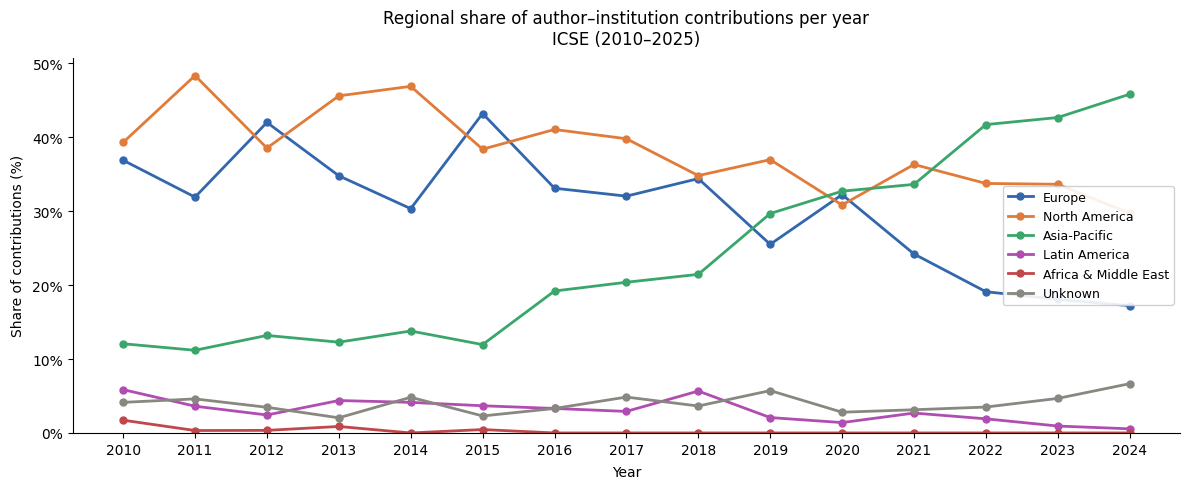

Saved → figures/isce_fig_region_line.png


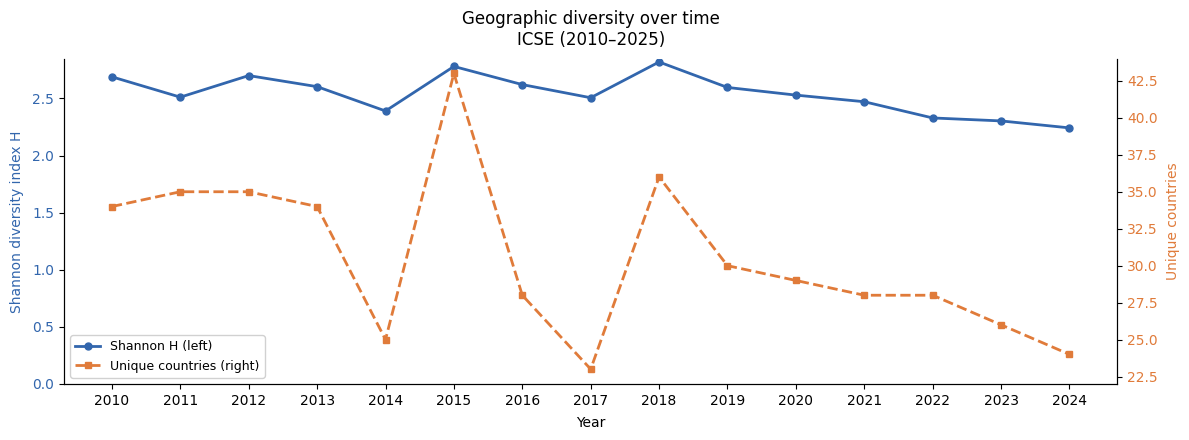

Saved → figures/isce_fig_diversity.png


In [43]:
fig, ax = plt.subplots(figsize=(12, 5))
 
for region in REGION_ORDER:
    if region not in region_pct.columns:
        continue
    vals = region_pct[region]
    if vals.max() < 1:
        continue  # skip regions with negligible presence
    ax.plot(
        years, vals,
        "o-",
        color=REGION_COLORS[region],
        linewidth=2,
        markersize=5,
        label=region,
    )
 
ax.set_xlabel("Year", labelpad=6)
ax.set_ylabel("Share of contributions (%)", labelpad=6)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xticks(years)
ax.set_ylim(bottom=0)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="center right", fontsize=9, framealpha=0.9)
ax.set_title(
    "Regional share of author–institution contributions per year\n"
    "ICSE (2010–2025)",
    pad=10,
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "isce_fig_region_line.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/isce_fig_region_line.png")

 
# ── Plot 3: Shannon diversity index over time ──────────────────────────────────
 
def shannon(counts):
    s = pd.Series(counts)
    s = s[s > 0]
    p = s / s.sum()
    return float(-(p * np.log(p)).sum())
 
diversity = []
for year, g in df.groupby("year"):
    cc_counts = g["country_code"].value_counts()
    diversity.append({
        "year":        year,
        "shannon_H":   round(shannon(cc_counts), 3),
        "n_countries": g["country_code"].nunique(),
        "n_papers":    g["doi"].nunique(),
    })
 
div_df = pd.DataFrame(diversity).set_index("year")
 
fig, ax1 = plt.subplots(figsize=(12, 4.5))
ax2 = ax1.twinx()
 
l1, = ax1.plot(div_df.index, div_df["shannon_H"], "o-",
               color="#3266ad", lw=2, ms=5, label="Shannon H (left)")
l2, = ax2.plot(div_df.index, div_df["n_countries"], "s--",
               color="#e07b3a", lw=2, ms=5, label="Unique countries (right)")
 
ax1.set_xlabel("Year", labelpad=6)
ax1.set_ylabel("Shannon diversity index H", color="#3266ad", labelpad=6)
ax2.set_ylabel("Unique countries", color="#e07b3a", labelpad=6)
ax1.tick_params(axis="y", labelcolor="#3266ad")
ax2.tick_params(axis="y", labelcolor="#e07b3a")
ax1.set_xticks(div_df.index)
ax1.set_ylim(bottom=0)
ax1.spines[["top"]].set_visible(False)
ax2.spines[["top"]].set_visible(False)
 
lines = [l1, l2]
ax1.legend(lines, [l.get_label() for l in lines],
           loc="lower left", fontsize=9, framealpha=0.9)
ax1.set_title("Geographic diversity over time\nICSE (2010–2025)", pad=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "isce_fig_diversity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/isce_fig_diversity.png")

      shannon_H  H_max  evenness  n_countries  n_papers
year                                                   
2010      2.689  3.526     0.763           34       209
2011      2.511  3.555     0.706           35       212
2012      2.700  3.555     0.759           35       228
2013      2.603  3.526     0.738           34       236
2014      2.390  3.219     0.743           25        99
2015      2.780  3.761     0.739           43       296
2016      2.621  3.332     0.787           28        99
2017      2.506  3.135     0.799           23        67
2018      2.819  3.584     0.787           36       149
2019      2.596  3.401     0.763           30       109
2020      2.529  3.367     0.751           29       128
2021      2.471  3.332     0.742           28       137
2022      2.329  3.332     0.699           28       196
2023      2.303  3.258     0.707           26       210
2024      2.242  3.178     0.705           24       237


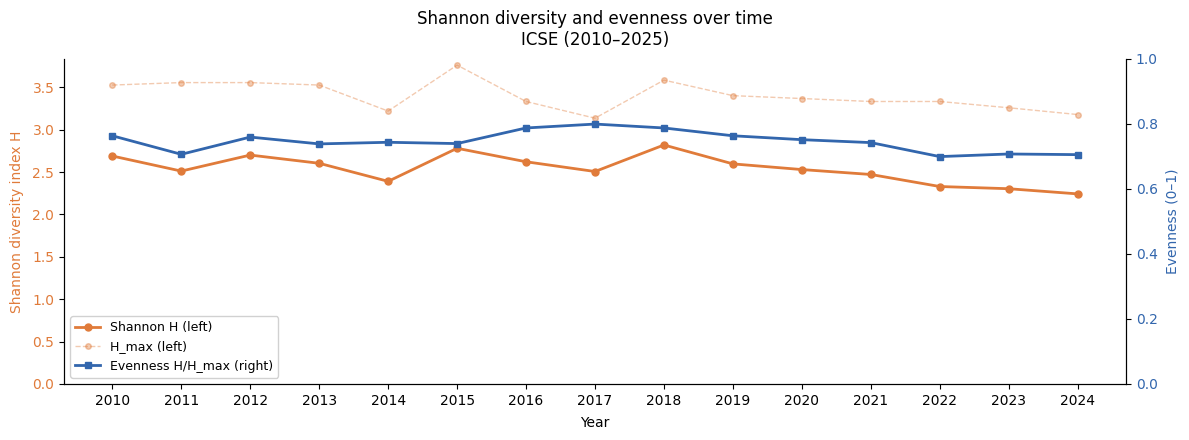

Saved → figures/isce_fig_evenness.png


In [44]:
# ── Shannon H and Evenness over time ──────────────────────────────────────────

import numpy as np

diversity = []
for year, g in df.groupby("year"):
    cc_counts = g["country_code"].value_counts()
    n = len(cc_counts)
    
    # Shannon H
    p = cc_counts / cc_counts.sum()
    H = float(-(p * np.log(p)).sum())
    
    # Evenness (H / H_max)
    H_max = np.log(n) if n > 1 else 1
    evenness = round(H / H_max, 3)
    
    diversity.append({
        "year":        year,
        "shannon_H":   round(H, 3),
        "H_max":       round(H_max, 3),
        "evenness":    evenness,
        "n_countries": n,
        "n_papers":    g["doi"].nunique(),
    })

div_df = pd.DataFrame(diversity).set_index("year")
print(div_df.to_string())

# ── Plot Shannon H and Evenness ────────────────────────────────────────────────

fig, ax1 = plt.subplots(figsize=(12, 4.5))
ax2 = ax1.twinx()

l1, = ax1.plot(div_df.index, div_df["shannon_H"], "o-",
               color="#e07b3a", lw=2, ms=5, label="Shannon H (left)")
l2, = ax1.plot(div_df.index, div_df["H_max"], "o--",
               color="#e07b3a", lw=1, ms=4, alpha=0.4, label="H_max (left)")
l3, = ax2.plot(div_df.index, div_df["evenness"], "s-",
               color="#3266ad", lw=2, ms=5, label="Evenness H/H_max (right)")

ax1.set_xlabel("Year", labelpad=6)
ax1.set_ylabel("Shannon diversity index H", color="#e07b3a", labelpad=6)
ax2.set_ylabel("Evenness (0–1)", color="#3266ad", labelpad=6)
ax1.tick_params(axis="y", labelcolor="#e07b3a")
ax2.tick_params(axis="y", labelcolor="#3266ad")
ax2.set_ylim(0, 1)
ax1.set_xticks(div_df.index)
ax1.set_ylim(bottom=0)
ax1.spines[["top"]].set_visible(False)
ax2.spines[["top"]].set_visible(False)

lines = [l1, l2, l3]
ax1.legend(lines, [l.get_label() for l in lines],
           loc="lower left", fontsize=9, framealpha=0.9)
ax1.set_title("Shannon diversity and evenness over time\nICSE (2010–2025)", pad=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "isce_fig_evenness.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/isce_fig_evenness.png")

using amy's region mapping to create a time series

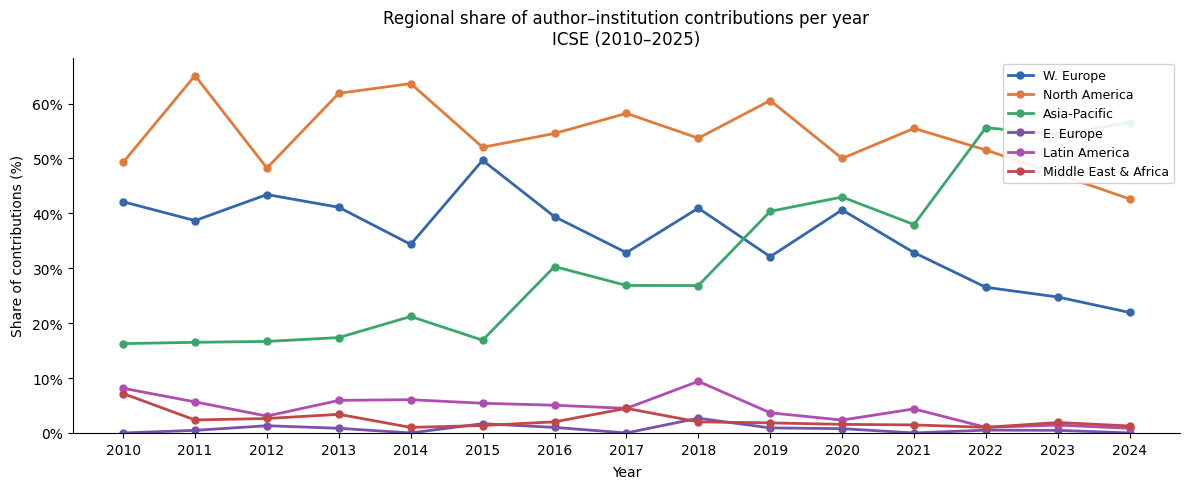

Saved → figures/isce_fig_region_line2.png


In [45]:
# ── Region order and colors matching teammate's mapping ────────────────────────

REGION_MAP = {
    "US": "North America", "CA": "North America", "MX": "North America",
    "BM": "North America", "GL": "North America",
    "DE": "W. Europe", "FR": "W. Europe", "GB": "W. Europe",
    "NL": "W. Europe", "IT": "W. Europe", "ES": "W. Europe",
    "SE": "W. Europe", "CH": "W. Europe", "AT": "W. Europe",
    "BE": "W. Europe", "FI": "W. Europe", "DK": "W. Europe",
    "NO": "W. Europe", "PT": "W. Europe", "IE": "W. Europe",
    "LU": "W. Europe", "GR": "W. Europe", "IS": "W. Europe",
    "MT": "W. Europe",
    "CZ": "E. Europe", "PL": "E. Europe", "HU": "E. Europe",
    "RO": "E. Europe", "SK": "E. Europe", "HR": "E. Europe",
    "RS": "E. Europe", "SI": "E. Europe", "BG": "E. Europe",
    "RU": "E. Europe", "EE": "E. Europe", "MK": "E. Europe",
    "CN": "Asia-Pacific", "JP": "Asia-Pacific", "AU": "Asia-Pacific",
    "KR": "Asia-Pacific", "SG": "Asia-Pacific", "HK": "Asia-Pacific",
    "TW": "Asia-Pacific", "IN": "Asia-Pacific", "NZ": "Asia-Pacific",
    "TH": "Asia-Pacific", "MY": "Asia-Pacific", "ID": "Asia-Pacific",
    "PK": "Asia-Pacific", "VN": "Asia-Pacific", "MO": "Asia-Pacific",
    "BR": "Latin America", "AR": "Latin America", "CL": "Latin America",
    "CO": "Latin America", "UY": "Latin America", "PE": "Latin America",
    "BB": "Latin America", "EC": "Latin America",
    "IL": "Middle East & Africa", "SA": "Middle East & Africa",
    "EG": "Middle East & Africa", "ZA": "Middle East & Africa",
    "IR": "Middle East & Africa", "AE": "Middle East & Africa",
    "TN": "Middle East & Africa", "DZ": "Middle East & Africa",
    "LY": "Middle East & Africa", "KW": "Middle East & Africa",
    "PS": "Middle East & Africa", "JO": "Middle East & Africa",
    "TR": "Middle East & Africa", "MA": "Middle East & Africa",
    "NA": "Middle East & Africa",
}

REGION_ORDER = [
    "W. Europe", "North America", "Asia-Pacific",
    "E. Europe", "Latin America", "Middle East & Africa", "Other"
]

REGION_COLORS = {
    "W. Europe":            "#3266ad",
    "North America":        "#e07b3a",
    "Asia-Pacific":         "#3aa66b",
    "E. Europe":            "#7b52ab",
    "Latin America":        "#b04db0",
    "Middle East & Africa": "#c0474a",
    "Other":                "#888780",
}

# ── Apply region mapping ───────────────────────────────────────────────────────

df["region"] = df["country_code"].map(REGION_MAP).fillna("Other")

# ── Build per-year region percentages ─────────────────────────────────────────

# deduplicate: one row per (doi, country_code) then map to region
# a paper can appear in multiple regions if it has authors from multiple regions
doi_region = (
    df.drop_duplicates(subset=["doi", "country_code"])
    .assign(region=lambda x: x["country_code"].map(REGION_MAP).fillna("Other"))
    .drop_duplicates(subset=["doi", "year", "region"])
)

region_year = (
    doi_region.groupby(["year", "region"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=REGION_ORDER, fill_value=0)
)
year_totals = doi_region.drop_duplicates(subset=["doi", "year"]).groupby("year").size()
region_pct = region_year.div(year_totals, axis=0) * 100
years = region_pct.index.tolist()

# ── Plot: Line chart — regional share over time ────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 5))

for region in REGION_ORDER:
    if region not in region_pct.columns:
        continue
    vals = region_pct[region]
    if vals.max() < 1:
        continue
    ax.plot(
        years, vals,
        "o-",
        color=REGION_COLORS[region],
        linewidth=2,
        markersize=5,
        label=region,
    )

ax.set_xlabel("Year", labelpad=6)
ax.set_ylabel("Share of contributions (%)", labelpad=6)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xticks(years)
ax.set_ylim(bottom=0)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper right", fontsize=9, framealpha=0.9)
ax.set_title(
    "Regional share of author–institution contributions per year\n"
    "ICSE (2010–2025)",
    pad=10,
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "isce_fig_region_line2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/isce_fig_region_line2.png")

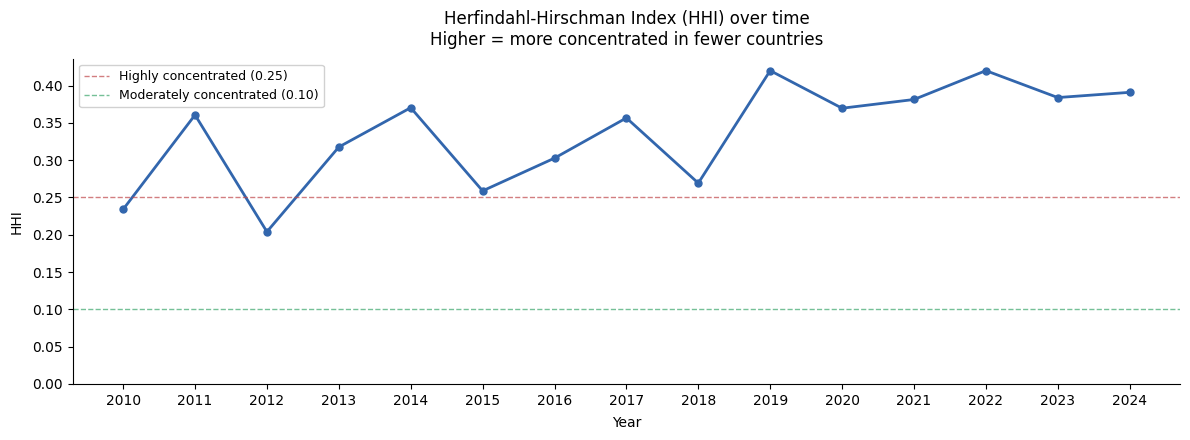

Saved → isce_fig_hhi.png


In [46]:
# ══════════════════════════════════════════════════════════════════════════════
# GRAPH 1: HHI over time
# ══════════════════════════════════════════════════════════════════════════════
 
hhi_rows = []
for year, g in df.groupby("year"):
    dois = g.drop_duplicates(subset=["doi", "country_code"])
    total = dois["doi"].nunique()
    cc_counts = dois.groupby("country_code")["doi"].nunique()
    p = cc_counts / total
    hhi = float((p ** 2).sum())
    hhi_rows.append({"year": year, "hhi": round(hhi, 4)})
 
hhi_df = pd.DataFrame(hhi_rows).set_index("year")
 
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(hhi_df.index, hhi_df["hhi"], "o-", color="#3266ad", lw=2, ms=5)
 
# reference lines
ax.axhline(0.25, color="#c0474a", lw=1, linestyle="--", alpha=0.7, label="Highly concentrated (0.25)")
ax.axhline(0.10, color="#3aa66b", lw=1, linestyle="--", alpha=0.7, label="Moderately concentrated (0.10)")
 
ax.set_xlabel("Year", labelpad=6)
ax.set_ylabel("HHI", labelpad=6)
ax.set_xticks(hhi_df.index)
ax.set_ylim(bottom=0)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(fontsize=9, framealpha=0.9)
ax.set_title("Herfindahl-Hirschman Index (HHI) over time\n"
             "Higher = more concentrated in fewer countries", pad=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "isce_fig_hhi.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → isce_fig_hhi.png")

In [47]:
COUNTRY_NAMES = {
    "AU": "Australia",    "AT": "Austria",      "BE": "Belgium",
    "BR": "Brazil",       "CA": "Canada",       "CL": "Chile",
    "CN": "China",        "CZ": "Czech Rep.",   "DE": "Germany",
    "DK": "Denmark",      "DZ": "Algeria",      "ES": "Spain",
    "FI": "Finland",      "FR": "France",       "GB": "United Kingdom",
    "GR": "Greece",       "HR": "Croatia",      "HU": "Hungary",
    "IE": "Ireland",      "IN": "India",        "IS": "Iceland",
    "IT": "Italy",        "JO": "Jordan",       "LU": "Luxembourg",
    "MX": "Mexico",       "NL": "Netherlands",  "NO": "Norway",
    "NZ": "New Zealand",  "PL": "Poland",       "PT": "Portugal",
    "RO": "Romania",      "SE": "Sweden",       "SG": "Singapore",
    "SI": "Slovenia",     "TH": "Thailand",     "TN": "Tunisia",
    "TR": "Turkey",       "US": "United States","CH": "Switzerland",
    "AR": "Argentina",    "KR": "South Korea",  "JP": "Japan",
    "HK": "Hong Kong",    "TW": "Taiwan",       "MY": "Malaysia",
    "ID": "Indonesia",    "PK": "Pakistan",     "VN": "Vietnam",
    "ZA": "South Africa", "EG": "Egypt",        "IL": "Israel",
    "RS": "Serbia",       "SK": "Slovakia",     "BG": "Bulgaria",
    "RU": "Russia",       "EE": "Estonia",      "MK": "N. Macedonia",
    "CO": "Colombia",     "UY": "Uruguay",      "PE": "Peru",
}

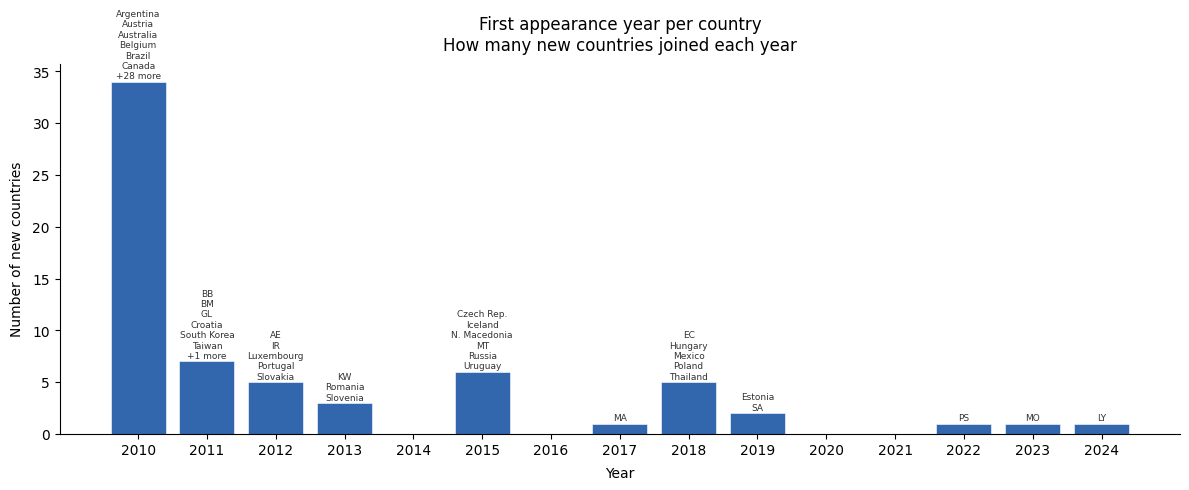

Saved → icse_fig_first_appearance.png


In [48]:
 # ══════════════════════════════════════════════════════════════════════════════
# GRAPH 2: First appearance year per country
# ══════════════════════════════════════════════════════════════════════════════
 
first_year = (
    df.dropna(subset=["country_code"])
    .groupby("country_code")["year"]
    .min()
    .reset_index()
    .rename(columns={"year": "first_year"})
)
first_year["country_name"] = first_year["country_code"].map(
    lambda x: COUNTRY_NAMES.get(x, x)
)
 
# count how many countries first appeared each year
debut_counts = first_year.groupby("first_year").size().reset_index(name="n_new_countries")
# get list of country names per debut year for annotation
debut_names = first_year.groupby("first_year")["country_name"].apply(list)
 
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(debut_counts["first_year"], debut_counts["n_new_countries"],
              color="#3266ad", edgecolor="white", linewidth=0.4)
 
# annotate bars with country names
for year, names in debut_names.items():
    n = len(names)
    label = "\n".join(names[:6])  # show max 6 to avoid overflow
    if len(names) > 6:
        label += f"\n+{len(names)-6} more"
    ax.text(year, n + 0.1, label, ha="center", va="bottom", fontsize=6.5, color="#333")
 
ax.set_xlabel("Year", labelpad=6)
ax.set_ylabel("Number of new countries", labelpad=6)
ax.set_xticks(sorted(df["year"].unique()))
ax.set_ylim(bottom=0)
ax.spines[["top", "right"]].set_visible(False)
ax.set_title("First appearance year per country\n"
             "How many new countries joined each year", pad=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "isce_fig_first_appearance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → icse_fig_first_appearance.png")
 

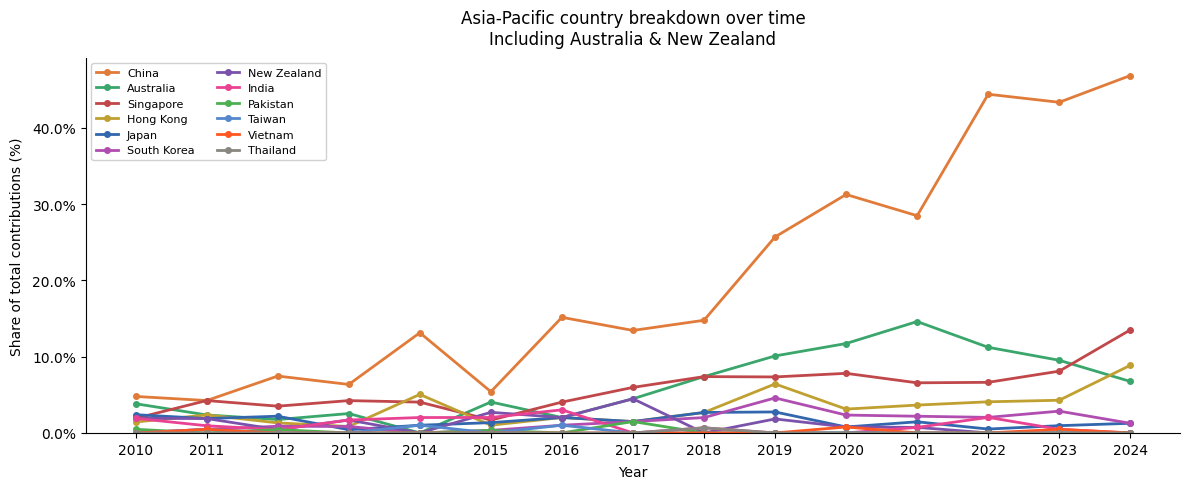

Saved → icse_fig_apac_breakdown_full.png


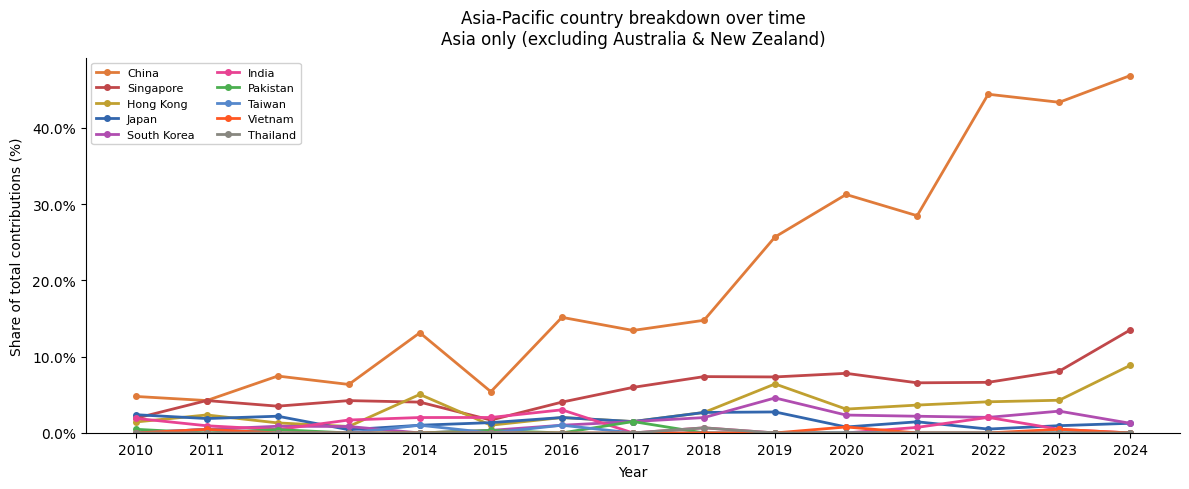

Saved → icse_fig_apac_breakdown_asia_only.png


In [50]:
# ══════════════════════════════════════════════════════════════════════════════
# GRAPH 3a: Asia-Pacific breakdown (including Australia & NZ)
# GRAPH 3b: Asia only (excluding Australia & NZ)
# ══════════════════════════════════════════════════════════════════════════════

APAC_CODES = ["CN", "JP", "AU", "KR", "SG", "HK", "TW", "IN", "NZ",
              "TH", "MY", "ID", "PK", "VN", "MO"]

ASIA_ONLY_CODES = ["CN", "JP", "KR", "SG", "HK", "TW", "IN",
                   "TH", "MY", "ID", "PK", "VN", "MO"]

APAC_NAMES = {
    "CN": "China", "JP": "Japan", "AU": "Australia", "KR": "South Korea",
    "SG": "Singapore", "HK": "Hong Kong", "TW": "Taiwan", "IN": "India",
    "NZ": "New Zealand", "TH": "Thailand", "MY": "Malaysia",
    "ID": "Indonesia", "PK": "Pakistan", "VN": "Vietnam", "MO": "Macao"
}

# distinct colors for each country
COUNTRY_COLORS = {
    "CN": "#e07b3a",   # orange — China will likely dominate
    "JP": "#3266ad",   # blue
    "AU": "#3aa66b",   # green
    "KR": "#b04db0",   # purple
    "SG": "#c0474a",   # red
    "HK": "#c0a030",   # gold
    "TW": "#5588cc",   # light blue
    "IN": "#e84393",   # pink
    "NZ": "#7b52ab",   # violet
    "TH": "#888780",   # grey
    "MY": "#00838f",   # teal
    "ID": "#a05000",   # brown
    "PK": "#4caf50",   # lime
    "VN": "#ff5722",   # deep orange
    "MO": "#607d8b",   # blue grey
}

year_totals = df.drop_duplicates(subset=["doi", "year"]).groupby("year")["doi"].nunique()

def plot_apac_breakdown(country_codes, title_suffix, filename):
    df_sub = (
        df[df["country_code"].isin(country_codes)]
        .drop_duplicates(subset=["doi", "country_code"])
    )
    apac_year_country = (
        df_sub.groupby(["year", "country_code"])["doi"]
        .nunique()
        .unstack(fill_value=0)
    )
    col_order = apac_year_country.sum().sort_values(ascending=False).index.tolist()
    apac_pct = apac_year_country[col_order].div(year_totals, axis=0) * 100

    fig, ax = plt.subplots(figsize=(12, 5))
    for cc in col_order:
        if apac_pct[cc].max() < 0.5:
            continue
        ax.plot(apac_pct.index, apac_pct[cc], "o-",
                color=COUNTRY_COLORS.get(cc, "#333333"),
                lw=2, ms=4, label=APAC_NAMES.get(cc, cc))

    ax.set_xlabel("Year", labelpad=6)
    ax.set_ylabel("Share of total contributions (%)", labelpad=6)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_xticks(sorted(df["year"].unique()))
    ax.set_ylim(bottom=0)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(loc="upper left", fontsize=8, framealpha=0.9, ncol=2)
    ax.set_title(f"Asia-Pacific country breakdown over time\n{title_suffix}", pad=10)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {filename}")

plot_apac_breakdown(
    APAC_CODES,
    "Including Australia & New Zealand",
    "icse_fig_apac_breakdown_full.png"
)

plot_apac_breakdown(
    ASIA_ONLY_CODES,
    "Asia only (excluding Australia & New Zealand)",
    "icse_fig_apac_breakdown_asia_only.png"
)